# Pranay Sai's Contribution

## Hence all the images have been resized so next we will separate the images according to the classes for labelling

In [10]:
import json
import os
import shutil

# Paths
json_path = '/Users/nithish/Downloads/Yelp Photos/yelp_photos/photos.json'
image_folder = '/Users/nithish/Desktop/Yelp JSON/Yelp Photos/yelp_photos/photos'
output_folder = '/Users/nithish/Desktop/Yelp JSON/Yelp Photos/yelp_photos/labeled_photos'  # output folder for sorted images by label

# Create output folder if not exists
os.makedirs(output_folder, exist_ok=True)

# Load JSON lines
with open(json_path, 'r') as f:
    lines = f.readlines()

photo_data = [json.loads(line) for line in lines]

# Process each photo
count_copied = 0
for entry in photo_data:
    photo_id = entry.get('photo_id')
    label = entry.get('label')

    # Skip if label is missing
    if not label:
        continue

    # Construct filenames
    filename_jpg = photo_id + '.jpg'
    filename_png = photo_id + '.png'

    # Check file existence and source path
    src_path = None
    if os.path.exists(os.path.join(image_folder, filename_jpg)):
        src_path = os.path.join(image_folder, filename_jpg)
    elif os.path.exists(os.path.join(image_folder, filename_png)):
        src_path = os.path.join(image_folder, filename_png)

    if src_path:
        # Create label folder inside output folder
        label_folder = os.path.join(output_folder, label)
        os.makedirs(label_folder, exist_ok=True)

        # Destination path
        dest_path = os.path.join(label_folder, os.path.basename(src_path))

        # Copy the image to the label folder
        shutil.copy2(src_path, dest_path)
        count_copied += 1

print(f"Copied {count_copied} images into labeled folders inside '{output_folder}'")

Copied 199994 images into labeled folders inside '/Users/nithish/Desktop/Yelp JSON/Yelp Photos/yelp_photos/labeled_photos'


## Balancing label photos as Menu has less photos i.e, 1678 so we tried to desample the other photos from other labeled data to avoid biasing

In [33]:
import os
import shutil
import random

# Original labeled data folder
source_dir = '/Users/nithish/Desktop/Yelp JSON/Yelp Photos/yelp_photos/labeled_photos'
# New folder to store balanced data
dest_dir = '/Users/nithish/Desktop/Yelp JSON/Yelp Photos/yelp_photos/balanced_photos'
os.makedirs(dest_dir, exist_ok=True)

# Desired number of images per class
target_counts = {

    'drink': 5000,
}

# Loop through each specified label
for label, target_count in target_counts.items():
    label_path = os.path.join(source_dir, label)
    if not os.path.isdir(label_path):
        print(f"⚠️ Warning: Folder not found for label '{label}'. Skipping.")
        continue

    # Get all image file names
    all_images = os.listdir(label_path)

    # If not enough images, take as many as available
    if len(all_images) < target_count:
        print(f"⚠️ Only {len(all_images)} images available for {label}. Sampling all.")
        sampled_images = all_images
    else:
        sampled_images = random.sample(all_images, target_count)

    # Create destination label folder
    label_dest = os.path.join(dest_dir, label)
    os.makedirs(label_dest, exist_ok=True)

    # Copy sampled images
    for img in sampled_images:
        src = os.path.join(label_path, img)
        dst = os.path.join(label_dest, img)
        shutil.copy2(src, dst)

    print(f"✅ {label}: Copied {len(sampled_images)} images.")

print("\n🎯 Custom balancing complete.")


✅ drink: Copied 5000 images.

🎯 Custom balancing complete.


## Resized all the photos after balancing

In [18]:
from PIL import Image
import os

# Paths
input_dir = '/Users/nithish/Desktop/Yelp JSON/Yelp Photos/yelp_photos/balanced_photos'
output_dir = '/Users/nithish/Desktop/Yelp JSON/Yelp Photos/yelp_photos/resized_photos'
os.makedirs(output_dir, exist_ok=True)

# Resize target
target_size = (64, 64)  # or (224, 224) for CNNs

# Resize each image and save
for label in os.listdir(input_dir):
    label_input_path = os.path.join(input_dir, label)
    label_output_path = os.path.join(output_dir, label)
    os.makedirs(label_output_path, exist_ok=True)

    for file in os.listdir(label_input_path):
        input_path = os.path.join(label_input_path, file)
        output_path = os.path.join(label_output_path, file)

        try:
            img = Image.open(input_path).convert('RGB')
            img = img.resize(target_size)
            img.save(output_path)
        except Exception as e:
            print(f"❌ Failed to process {input_path}: {e}")

    print(f"✅ Resized all images in {label}")

print("\n🎯 All images resized and saved to:", output_dir)


✅ Resized all images in outside
✅ Resized all images in inside
✅ Resized all images in menu
✅ Resized all images in food
✅ Resized all images in drink

🎯 All images resized and saved to: /Users/nithish/Desktop/Yelp JSON/Yelp Photos/yelp_photos/resized_photos


In [34]:
import os
import numpy as np
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img

# === Setup ===
input_dir = '/Users/nithish/Desktop/Yelp JSON/Yelp Photos/yelp_photos/balanced_photos'
output_dir = '/Users/nithish/Desktop/Yelp JSON/Yelp Photos/yelp_photos/resized_images_112'
os.makedirs(output_dir, exist_ok=True)

resize_size = (112, 112)

# === Step 1: Resize all images ===
for label in os.listdir(input_dir):
    label_input_path = os.path.join(input_dir, label)
    label_output_path = os.path.join(output_dir, label)
    os.makedirs(label_output_path, exist_ok=True)

    if not os.path.isdir(label_input_path):
        continue

    for img_name in os.listdir(label_input_path):
        if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        try:
            img_path = os.path.join(label_input_path, img_name)
            img = Image.open(img_path).convert('RGB')
            img = img.resize(resize_size)
            img.save(os.path.join(label_output_path, img_name))
        except Exception as e:
            print(f"❌ Failed to resize {img_name}: {e}")
    print(f"✅ Resized all images in: {label}")

# === Step 2: Augment 'menu' class to reach 5,000 images ===
menu_path = os.path.join(output_dir, 'menu')
augmented_tmp = os.path.join(menu_path, 'temp_augmented')
os.makedirs(augmented_tmp, exist_ok=True)

# Count how many original resized menu images
menu_images = [f for f in os.listdir(menu_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
n_original = len(menu_images)
n_needed = 5000 - n_original
print(f"🔄 Augmenting {n_needed} new images for 'menu'...")

# Load all resized menu images
img_arrays = []
for img_file in menu_images:
    try:
        img = load_img(os.path.join(menu_path, img_file), target_size=resize_size)
        img_array = img_to_array(img)
        img_arrays.append(img_array)
    except:
        continue

img_arrays = np.array(img_arrays)

# Augmentor setup
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Generate images
count = 0
for batch in datagen.flow(img_arrays, batch_size=32, save_to_dir=augmented_tmp, save_format='jpg'):
    count += len(batch)
    if count >= n_needed:
        break

# Move augmented files to main menu folder
for f in os.listdir(augmented_tmp):
    src = os.path.join(augmented_tmp, f)
    dst = os.path.join(menu_path, f"aug_{f}")
    os.rename(src, dst)

# Cleanup
os.rmdir(augmented_tmp)

print(f"✅ Finished: 'menu' now has approximately {len(os.listdir(menu_path))} images.")
print("🎯 All images resized to 112×112 and saved to:", output_dir)


✅ Resized all images in: outside
✅ Resized all images in: inside
✅ Resized all images in: menu
✅ Resized all images in: food
✅ Resized all images in: drink
🔄 Augmenting 3322 new images for 'menu'...
✅ Finished: 'menu' now has approximately 5020 images.
🎯 All images resized to 112×112 and saved to: /Users/nithish/Desktop/Yelp JSON/Yelp Photos/yelp_photos/resized_images_112


# Without PCA

=== Classification Report ===
              precision    recall  f1-score   support

       drink       0.62      0.40      0.48        20
        food       0.50      0.15      0.23        20
      inside       0.22      0.50      0.30        20
        menu       0.38      0.50      0.43        20
     outside       0.56      0.25      0.34        20

    accuracy                           0.36       100
   macro avg       0.45      0.36      0.36       100
weighted avg       0.45      0.36      0.36       100



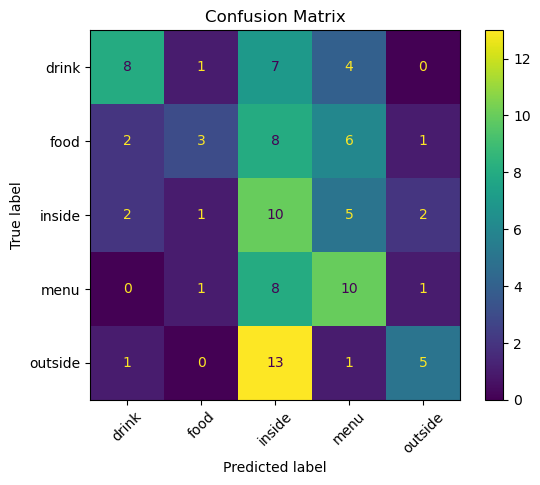

AUC Score: 0.68


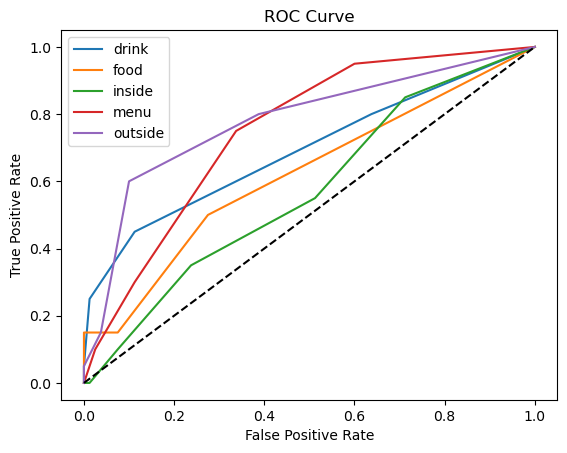

In [24]:
import os
import numpy as np
from PIL import Image
import random
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt

# Paths and Settings
resized_path = '/Users/nithish/Desktop/Yelp JSON/Yelp Photos/yelp_photos/resized_photos'
image_size = (64, 64)

X = []
y = []

# Load 100 images per class (skip files like .DS_Store)
for label in os.listdir(resized_path):
    label_path = os.path.join(resized_path, label)
    
    if not os.path.isdir(label_path):
        continue  # ✅ Skip .DS_Store or other files

    all_images = [img for img in os.listdir(label_path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]
    selected_images = random.sample(all_images, min(100, len(all_images)))

    for img_name in selected_images:
        img_path = os.path.join(label_path, img_name)
        try:
            img = Image.open(img_path).convert('RGB')
            img = img.resize(image_size)
            img_array = np.array(img).flatten() / 255.0  # Normalize
            X.append(img_array)
            y.append(label)
        except:
            continue

X = np.array(X)
y = np.array(y)

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42)

# Train kNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
y_prob = knn.predict_proba(X_test)

# Classification report
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# AUC & ROC Curve
try:
    auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
    print(f"AUC Score: {auc:.2f}")
    for i in range(len(le.classes_)):
        fpr, tpr, _ = roc_curve(y_test == i, y_prob[:, i])
        plt.plot(fpr, tpr, label=le.classes_[i])
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()
except Exception as e:
    print("❌ ROC Error:", e)


### With PCA for 5000 photos each class

Original dimensions: 12288, After PCA: 200
=== Classification Report ===
              precision    recall  f1-score   support

       drink       0.46      0.24      0.31       637
        food       0.73      0.55      0.62      1952
      inside       0.41      0.28      0.34      1000
        menu       0.34      0.78      0.47      1004
     outside       0.69      0.61      0.65      1733

    accuracy                           0.53      6326
   macro avg       0.53      0.49      0.48      6326
weighted avg       0.58      0.53      0.53      6326



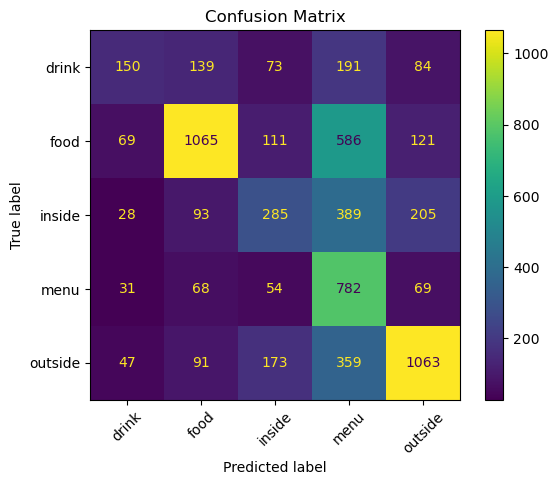

AUC Score: 0.77


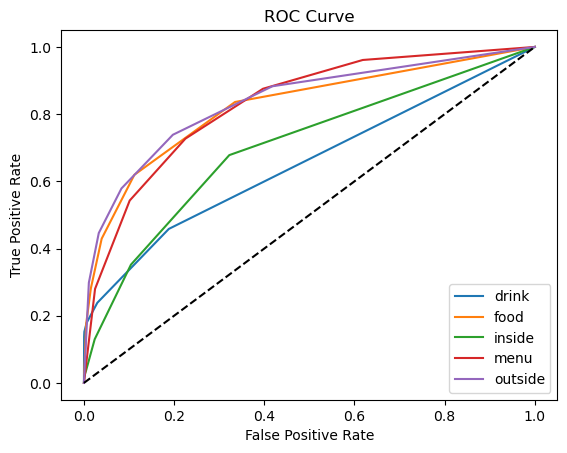

In [31]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# === Settings ===
resized_path = '/Users/nithish/Desktop/Yelp JSON/Yelp Photos/yelp_photos/resized_photos'
image_size = (64, 64)
X = []
y = []

# === Load all images from resized folders ===
for label in os.listdir(resized_path):
    label_path = os.path.join(resized_path, label)
    if not os.path.isdir(label_path):
        continue

    all_images = [img for img in os.listdir(label_path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]

    for img_name in all_images:
        img_path = os.path.join(label_path, img_name)
        try:
            img = Image.open(img_path).convert('RGB')
            img = img.resize(image_size)
            img_array = np.array(img).flatten() / 255.0
            X.append(img_array)
            y.append(label)
        except:
            continue

# === Prepare data ===
X = np.array(X)
y = np.array(y)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# === Train-test split ===
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42)

# === PCA ===
pca = PCA(n_components=200, random_state=42)  # Try 100, 200, or 300
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Original dimensions: {X.shape[1]}, After PCA: {X_train_pca.shape[1]}")

# === kNN on PCA-transformed data ===
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_pca, y_train)
y_pred = knn.predict(X_test_pca)
y_prob = knn.predict_proba(X_test_pca)

# === Evaluation ===
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# AUC & ROC Curve
try:
    auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
    print(f"AUC Score: {auc:.2f}")
    for i in range(len(le.classes_)):
        fpr, tpr, _ = roc_curve(y_test == i, y_prob[:, i])
        plt.plot(fpr, tpr, label=le.classes_[i])
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()
except Exception as e:
    print("❌ ROC Error:", e)


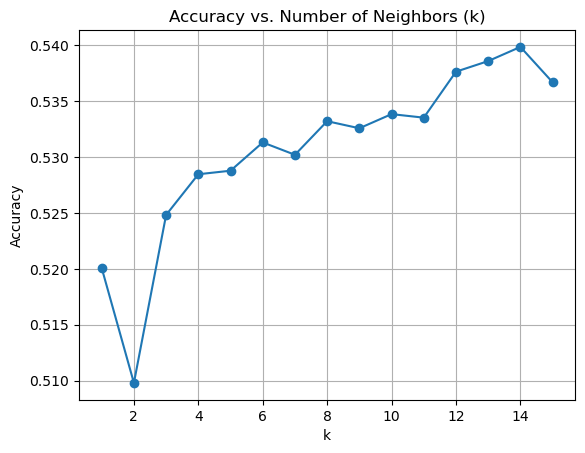

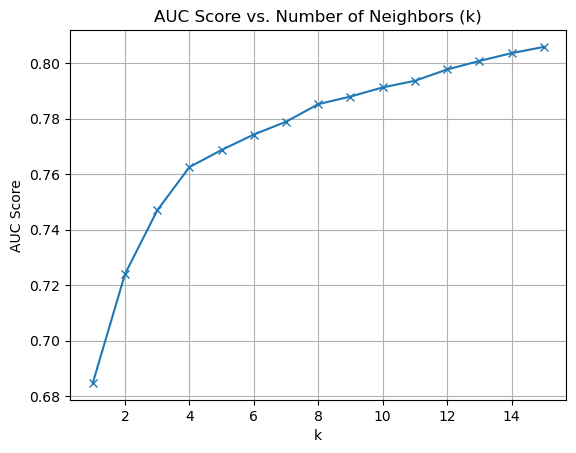

✅ Best k (accuracy): 14 → 0.5398
✅ Best k (AUC): 15 → 0.8059


In [32]:
from sklearn.metrics import accuracy_score

k_values = list(range(1, 16))
accuracies = []
auc_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_pca, y_train)
    y_pred_k = model.predict(X_test_pca)
    y_prob_k = model.predict_proba(X_test_pca)

    # Accuracy
    acc = accuracy_score(y_test, y_pred_k)
    accuracies.append(acc)

    # AUC
    try:
        auc_k = roc_auc_score(y_test, y_prob_k, multi_class='ovr')
    except:
        auc_k = 0
    auc_scores.append(auc_k)

# Plot Accuracy vs k
plt.plot(k_values, accuracies, marker='o')
plt.title("Accuracy vs. Number of Neighbors (k)")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# Plot AUC vs k
plt.plot(k_values, auc_scores, marker='x')
plt.title("AUC Score vs. Number of Neighbors (k)")
plt.xlabel("k")
plt.ylabel("AUC Score")
plt.grid(True)
plt.show()

# Best k based on accuracy and AUC
best_k_acc = k_values[np.argmax(accuracies)]
best_k_auc = k_values[np.argmax(auc_scores)]
print(f"✅ Best k (accuracy): {best_k_acc} → {max(accuracies):.4f}")
print(f"✅ Best k (AUC): {best_k_auc} → {max(auc_scores):.4f}")


after augmenting and again desampling the date images with differnt sizes from 5000 - 7000 photos per dataset

✅ Loaded 35620 images. Shape: (35620, 37632)
✅ PCA reduced dimensions: 37632 → 200

=== Classification Report ===
              precision    recall  f1-score   support

       drink       0.59      0.28      0.38      1436
        food       0.70      0.52      0.60      1951
      inside       0.41      0.26      0.32      1000
        menu       0.31      0.79      0.44      1004
     outside       0.63      0.66      0.65      1733

    accuracy                           0.51      7124
   macro avg       0.53      0.50      0.48      7124
weighted avg       0.57      0.51      0.50      7124



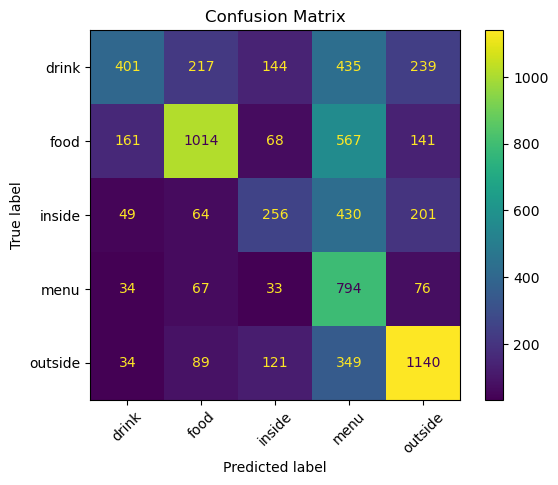

🎯 AUC Score: 0.8035


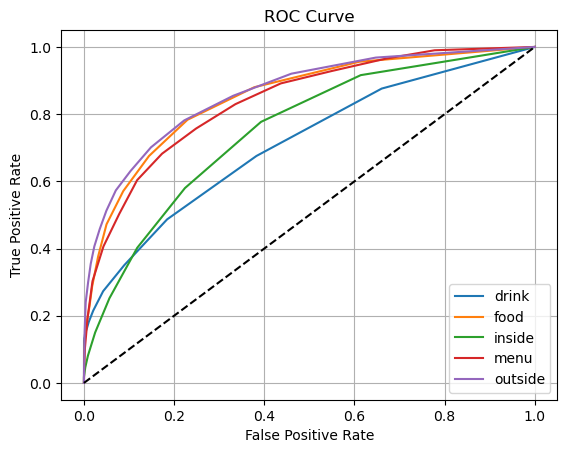

In [2]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

# === Paths and Settings ===
data_dir = '/Users/nithish/Desktop/Yelp JSON/Yelp Photos/yelp_photos/resized_images_112'
image_size = (112, 112)
X, y = [], []

# === Load all data safely ===
for label in sorted(os.listdir(data_dir)):
    label_path = os.path.join(data_dir, label)
    if not os.path.isdir(label_path):
        continue
    for img_name in os.listdir(label_path):
        if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        try:
            img_path = os.path.join(label_path, img_name)
            img = Image.open(img_path).convert('RGB')
            img_array = np.array(img).flatten() / 255.0
            if img_array.shape[0] == 112*112*3:
                X.append(img_array)
                y.append(label)
        except Exception as e:
            print(f"Error loading {img_name}: {e}")

# === Convert to arrays ===
X = np.array(X)
y = np.array(y)
print(f"✅ Loaded {len(X)} images. Shape: {X.shape}")

# === Encode labels ===
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# === Train-Test Split ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

# === PCA to reduce from 37632 to 200 ===
pca = PCA(n_components=200, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"✅ PCA reduced dimensions: {X.shape[1]} → {X_train_pca.shape[1]}")

# === Train kNN model ===
knn = KNeighborsClassifier(n_neighbors=14)  # Best k from tuning
knn.fit(X_train_pca, y_train)
y_pred = knn.predict(X_test_pca)
y_prob = knn.predict_proba(X_test_pca)

# === Evaluation ===
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# === Confusion Matrix ===
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# === AUC Score ===
try:
    auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
    print(f"🎯 AUC Score: {auc:.4f}")

    for i in range(len(le.classes_)):
        fpr, tpr, _ = roc_curve(y_test == i, y_prob[:, i])
        plt.plot(fpr, tpr, label=le.classes_[i])
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.grid(True)
    plt.show()
except Exception as e:
    print("❌ ROC Error:", e)


In [4]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Reuse the PCA-transformed features
X_train_pca, X_test_pca = X_train_pca, X_test_pca  # already computed

# Define the parameter grid
param_grid = {
    'n_neighbors': [16],  # best k from previous tuning
    'metric': ['euclidean'],  # best metric
    'weights': ['uniform', 'distance']
}

# Grid search
knn = KNeighborsClassifier()
grid = GridSearchCV(knn, param_grid, cv=5, n_jobs=-1)
grid.fit(X_train_pca, y_train)

# Print best result
print(f"✅ Best Weights: {grid.best_params_} → Accuracy: {grid.best_score_:.4f}")


✅ Best Weights: {'metric': 'euclidean', 'n_neighbors': 16, 'weights': 'distance'} → Accuracy: 0.5258


In [4]:
import os
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelBinarizer
from sklearn.ensemble import VotingClassifier
from PIL import Image



In [5]:
# === Settings ===
base_path = "/Users/nithish/Desktop/Yelp JSON/Yelp Photos/yelp_photos/balanced_labeled_photos"
image_size = (112, 112)
n_components = 200
k = 16
weighting = 'distance'
metric = 'euclidean'

In [6]:
# === Load Images and Labels ===
def load_images_from_folder(folder_path, label):
    images = []
    labels = []
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(folder_path, filename)
            try:
                img = Image.open(img_path).convert('RGB').resize(image_size)
                img_array = np.array(img).flatten()
                images.append(img_array)
                labels.append(label)
            except:
                continue
    return images, labels


In [7]:
# === Load all classes ===
X, y = [], []
class_names = ['drink', 'food', 'inside', 'menu', 'outside']
for cls in class_names:
    folder = os.path.join(base_path, cls)
    imgs, lbls = load_images_from_folder(folder, cls)
    X.extend(imgs)
    y.extend(lbls)

X = np.array(X)
y = np.array(y)

print(f"✅ Loaded {len(X)} images. Shape: {X.shape}")

✅ Loaded 94239 images. Shape: (94239, 37632)


In [8]:
# === Encode labels as numbers ===
label_map = {name: i for i, name in enumerate(class_names)}
y_encoded = np.array([label_map[label] for label in y])


In [9]:
# === Train/Test Split ===
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

In [10]:
import numpy as np
from sklearn.decomposition import PCA
import gc  # Garbage Collector

# Free up memory before starting PCA
gc.collect()

# Ensure your data is in float32 to save memory
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

# Apply PCA safely
n_components = 200  # Set this as needed
pca = PCA(n_components=n_components, random_state=42)

print("🔄 Applying PCA...")
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"✅ PCA applied: Original {X_train.shape[1]} → Reduced {X_train_pca.shape[1]}")

# Free memory from original inputs
del X_train
del X_test
gc.collect()


🔄 Applying PCA...
✅ PCA applied: Original 37632 → Reduced 200


0

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from sklearn.preprocessing import LabelBinarizer

# Train
knn = KNeighborsClassifier(n_neighbors=14, metric='euclidean', weights='distance')
knn.fit(X_train_pca, y_train)

# Predict
y_pred = knn.predict(X_test_pca)
probas = knn.predict_proba(X_test_pca)

# Evaluate
print("\n=== kNN Classification Report ===")
print(classification_report(y_test, y_pred))
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("✅ AUC Score:", roc_auc_score(LabelBinarizer().fit_transform(y_test), probas, average='macro'))
import matplotlib.pyplot as plt
import seaborn as sns


=== kNN Classification Report ===
              precision    recall  f1-score   support

           0       0.87      0.20      0.32      3134
           1       0.86      0.57      0.68      4000
           2       0.67      0.50      0.58      4000
           3       0.39      0.97      0.55      4000
           4       0.77      0.52      0.62      3714

    accuracy                           0.57     18848
   macro avg       0.71      0.55      0.55     18848
weighted avg       0.70      0.57      0.56     18848

✅ Accuracy: 0.5685483870967742
✅ AUC Score: 0.8689350563545266



=== Final Ensemble Classification Report ===
              precision    recall  f1-score   support

       drink       0.79      0.25      0.38      3134
        food       0.83      0.58      0.68      4000
      inside       0.65      0.49      0.56      4000
        menu       0.42      0.98      0.59      4000
     outside       0.73      0.54      0.62      3714

    accuracy                           0.58     18848
   macro avg       0.68      0.57      0.57     18848
weighted avg       0.68      0.58      0.57     18848

✅ Accuracy: 0.5823960101867572
✅ AUC Score: 0.8331984152931


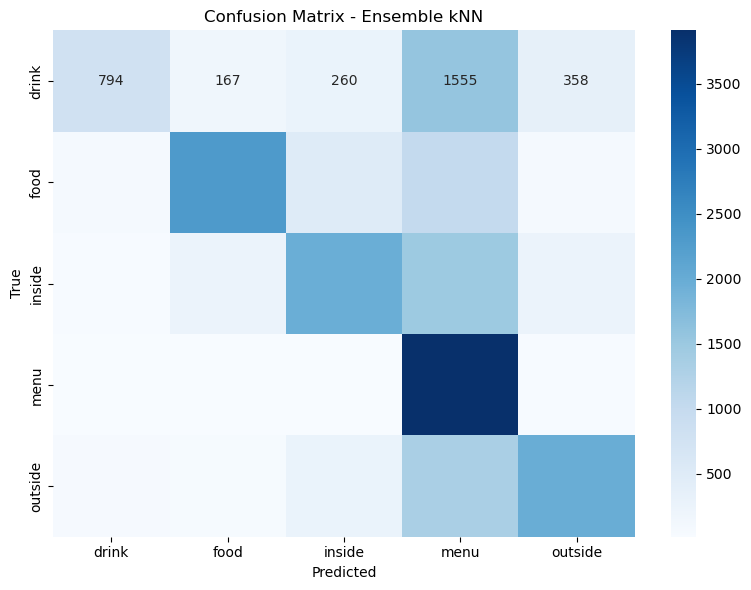

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


# === Step 4: Train individual kNN classifiers ===
knn_models = []
for class_idx in range(len(class_names)):
    binary_train_y = (y_train == class_idx).astype(int)
    knn = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
    knn.fit(X_train_pca, binary_train_y)
    knn_models.append(knn)

# === Step 5: Ensemble prediction ===
probas = np.zeros((X_test_pca.shape[0], len(class_names)))
for idx, model in enumerate(knn_models):
    probas[:, idx] = model.predict_proba(X_test_pca)[:, 1]

y_pred_ensemble = np.argmax(probas, axis=1)

# === Step 6: Evaluation ===
print("\n=== Final Ensemble Classification Report ===")
print(classification_report(y_test, y_pred_ensemble, target_names=class_names))
print("✅ Accuracy:", accuracy_score(y_test, y_pred_ensemble))
print("✅ AUC Score:", roc_auc_score(LabelBinarizer().fit_transform(y_test), probas, average='macro'))

# === Step 7: Confusion Matrix ===
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_ensemble), annot=True, fmt='d',
            xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title("Confusion Matrix - Ensemble kNN")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [58]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer


In [59]:
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)
class_names = lb.classes_


In [60]:
knn_drink = knn_models[0]
knn_food = knn_models[1]
knn_inside = knn_models[2]
knn_menu = knn_models[3]
knn_outside = knn_models[4]


In [61]:
probas_drink = knn_drink.predict_proba(X_test_pca)[:, 1]
probas_food = knn_food.predict_proba(X_test_pca)[:, 1]
probas_inside = knn_inside.predict_proba(X_test_pca)[:, 1]
probas_menu = knn_menu.predict_proba(X_test_pca)[:, 1]
probas_outside = knn_outside.predict_proba(X_test_pca)[:, 1]


In [39]:
# Save ensemble model as a dictionary of all 5 kNN models
ensemble_model = {
    'drink': knn_models[0],
    'food': knn_models[1],
    'inside': knn_models[2],
    'menu': knn_models[3],
    'outside': knn_models[4]
}

import joblib
joblib.dump(ensemble_model, "knn_ensemble_model.pkl")
print("✅ Ensemble model saved as knn_ensemble_model.pkl")


✅ Ensemble model saved as knn_ensemble_model.pkl


## updated the code to check for the overfitting or underfitting

In [1]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

# === Step 1: Load PCA-transformed data ===
npz_path = "/Users/nithish/Downloads/yelp_pca_data.npz"
data = np.load(npz_path)

X_train_pca = data['X_train_pca']
X_test_pca = data['X_test_pca']
y_train = data['y_train']
y_test = data['y_test']

print("✅ Loaded PCA data from .npz")
print(f"🔍 Shapes → X_train: {X_train_pca.shape}, X_test: {X_test_pca.shape}")

# === Step 2: Train kNN ===
k = 16
knn = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='euclidean')
knn.fit(X_train_pca, y_train)

# === Step 3: Predictions ===
y_train_pred = knn.predict(X_train_pca)
y_test_pred = knn.predict(X_test_pca)

# === Step 4: Accuracy ===
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"\n✅ Train Accuracy: {train_acc:.4f}")
print(f"✅ Test Accuracy:  {test_acc:.4f}")

# === Step 5: Classification Reports ===
print("\n📊 Train Classification Report:")
print(classification_report(y_train, y_train_pred, target_names=['drink', 'food', 'inside', 'menu', 'outside']))

print("\n📊 Test Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['drink', 'food', 'inside', 'menu', 'outside']))


✅ Loaded PCA data from .npz
🔍 Shapes → X_train: (75391, 200), X_test: (18848, 200)

✅ Train Accuracy: 1.0000
✅ Test Accuracy:  0.5633

📊 Train Classification Report:
              precision    recall  f1-score   support

       drink       1.00      1.00      1.00     12536
        food       1.00      1.00      1.00     16000
      inside       1.00      1.00      1.00     16000
        menu       1.00      1.00      1.00     16000
     outside       1.00      1.00      1.00     14855

    accuracy                           1.00     75391
   macro avg       1.00      1.00      1.00     75391
weighted avg       1.00      1.00      1.00     75391


📊 Test Classification Report:
              precision    recall  f1-score   support

       drink       0.86      0.19      0.31      3134
        food       0.86      0.56      0.68      4000
      inside       0.66      0.50      0.57      4000
        menu       0.39      0.97      0.55      4000
     outside       0.77      0.52      0.62

## clearly we can see that kNN model is overfitting


✅ Loaded PCA data
🔁 StandardScaler applied to PCA features
🚀 kNN training complete

✅ Train Accuracy: 1.0000
✅ Test Accuracy:  0.3492

📊 Train Classification Report:
              precision    recall  f1-score   support

       drink       1.00      1.00      1.00     12536
        food       1.00      1.00      1.00     16000
      inside       1.00      1.00      1.00     16000
        menu       1.00      1.00      1.00     16000
     outside       1.00      1.00      1.00     14855

    accuracy                           1.00     75391
   macro avg       1.00      1.00      1.00     75391
weighted avg       1.00      1.00      1.00     75391


📊 Test Classification Report:
              precision    recall  f1-score   support

       drink       0.91      0.16      0.28      3134
        food       0.97      0.28      0.44      4000
      inside       0.58      0.10      0.17      4000
        menu       0.26      0.99      0.41      4000
     outside       0.56      0.15      0.24

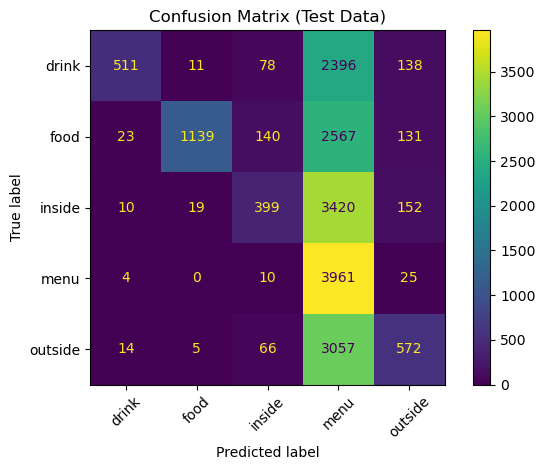

In [2]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# === Step 1: Load PCA-transformed data ===
npz_path = "/Users/nithish/Downloads/yelp_pca_data.npz"
data = np.load(npz_path)

X_train_pca = data['X_train_pca']
X_test_pca = data['X_test_pca']
y_train = data['y_train']
y_test = data['y_test']

print("✅ Loaded PCA data")

# === Step 2: Normalize PCA output ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_pca)
X_test_scaled = scaler.transform(X_test_pca)
print("🔁 StandardScaler applied to PCA features")

# === Step 3: Train kNN with smaller k ===
knn = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
knn.fit(X_train_scaled, y_train)
print("🚀 kNN training complete")

# === Step 4: Predictions ===
y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

# === Step 5: Accuracy ===
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"\n✅ Train Accuracy: {train_acc:.4f}")
print(f"✅ Test Accuracy:  {test_acc:.4f}")

# === Step 6: Classification Reports ===
target_names = ['drink', 'food', 'inside', 'menu', 'outside']
print("\n📊 Train Classification Report:")
print(classification_report(y_train, y_train_pred, target_names=target_names))

print("\n📊 Test Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=target_names))

# === Step 7: Confusion Matrix ===
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, display_labels=target_names, cmap='viridis')
plt.title("Confusion Matrix (Test Data)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### in the below code we tried to change the values of n neighbors weights and metrics to make the model 
We used k = 5 and uniform weighting (equal vote from 5 neighbors), model is not memorizing, it's generalizing

✅ Loaded PCA data
🚀 kNN training complete

✅ Train Accuracy: 0.6779
✅ Test Accuracy:  0.5802

📊 Train Classification Report:
              precision    recall  f1-score   support

       drink       0.85      0.41      0.55     12536
        food       0.87      0.70      0.78     16000
      inside       0.75      0.65      0.70     16000
        menu       0.48      0.99      0.65     16000
     outside       0.85      0.58      0.69     14855

    accuracy                           0.68     75391
   macro avg       0.76      0.66      0.67     75391
weighted avg       0.76      0.68      0.68     75391


📊 Test Classification Report:
              precision    recall  f1-score   support

       drink       0.73      0.27      0.40      3134
        food       0.80      0.59      0.68      4000
      inside       0.64      0.50      0.56      4000
        menu       0.42      0.97      0.59      4000
     outside       0.78      0.50      0.61      3714

    accuracy                 

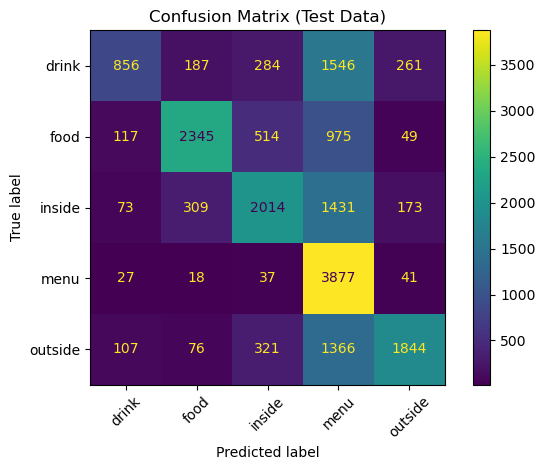

In [19]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# === Step 1: Load PCA-transformed data ===
npz_path = "/Users/nithish/Downloads/yelp_pca_data.npz"
data = np.load(npz_path)

X_train_pca = data['X_train_pca']
X_test_pca = data['X_test_pca']
y_train = data['y_train']
y_test = data['y_test']

print("✅ Loaded PCA data")

# === Step 2: Train kNN (no scaling, uniform weights) ===
knn = KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='euclidean')
knn.fit(X_train_pca, y_train)
print("🚀 kNN training complete")

# === Step 3: Predictions ===
y_train_pred = knn.predict(X_train_pca)
y_test_pred = knn.predict(X_test_pca)

# === Step 4: Accuracy ===
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"\n✅ Train Accuracy: {train_acc:.4f}")
print(f"✅ Test Accuracy:  {test_acc:.4f}")

# === Step 5: Classification Reports ===
target_names = ['drink', 'food', 'inside', 'menu', 'outside']
print("\n📊 Train Classification Report:")
print(classification_report(y_train, y_train_pred, target_names=target_names))

print("\n📊 Test Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=target_names))

# === Step 6: Confusion Matrix ===
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, display_labels=target_names, cmap='viridis')
plt.title("Confusion Matrix (Test Data)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


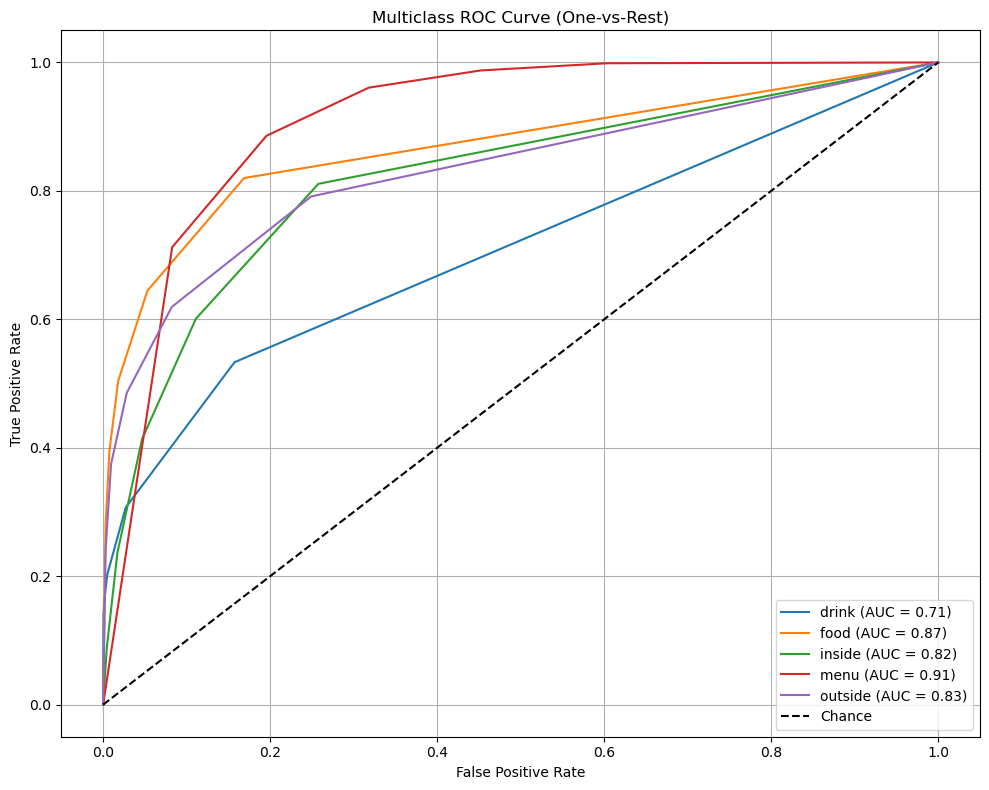

In [20]:
# === Step 7: AUC ROC Curve (Multiclass) ===
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
import matplotlib.pyplot as plt

# === Step 7.1: Use consistent full dataset ===
data = np.load("/Users/nithish/Downloads/yelp_pca_data.npz")
X_train_pca = data['X_train_pca']
y_train = data['y_train']
X_test_pca = data['X_test_pca']
y_test = data['y_test']

target_names = ['drink', 'food', 'inside', 'menu', 'outside']
n_classes = len(target_names)

# === Step 7.2: Binarize y for One-vs-Rest ===
y_train_bin = label_binarize(y_train, classes=list(range(n_classes)))
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))

# === Step 7.3: Wrap kNN in One-vs-Rest ===
ovr_knn = OneVsRestClassifier(
    KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='euclidean')
)
ovr_knn.fit(X_train_pca, y_train_bin)

# === Step 7.4: Predict Probabilities ===
y_score = ovr_knn.predict_proba(X_test_pca)

# === Step 7.5: Compute and Plot ROC Curves ===
fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'{target_names[i]} (AUC = {roc_auc[i]:.2f})')

# Diagonal line (random guess)
plt.plot([0, 1], [0, 1], 'k--', label='Chance')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


# NITHISH'S Contribution

# Model Evaluation

In [40]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_ensemble, target_names=class_names))


              precision    recall  f1-score   support

       drink       0.79      0.25      0.38      3134
        food       0.83      0.58      0.68      4000
      inside       0.65      0.49      0.56      4000
        menu       0.42      0.98      0.59      4000
     outside       0.73      0.54      0.62      3714

    accuracy                           0.58     18848
   macro avg       0.68      0.57      0.57     18848
weighted avg       0.68      0.58      0.57     18848



# Confusion Matrix

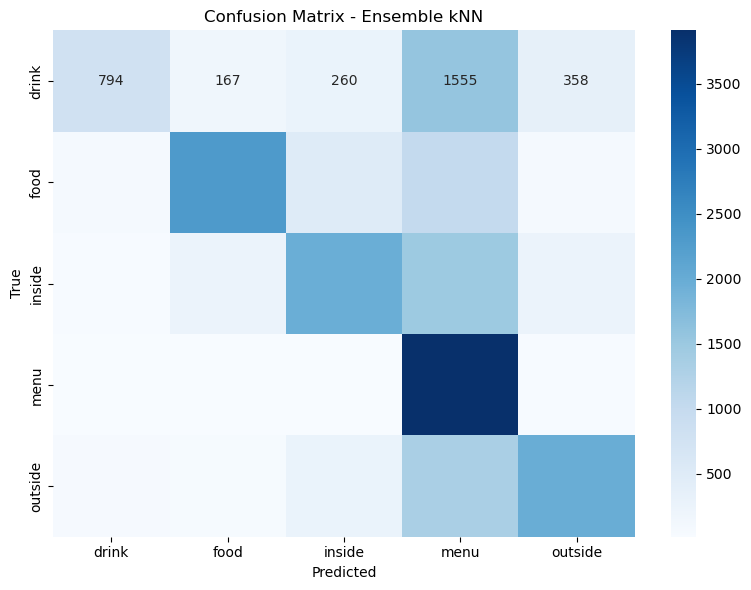

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_ensemble)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Ensemble kNN")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


In [42]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelBinarizer

lb = LabelBinarizer()
print("✅ AUC Score:", roc_auc_score(lb.fit_transform(y_test), probas_ensemble, average='macro'))


✅ AUC Score: 0.8331984152931


# Hyperparameter Tuning
testing different kNN parameters like number of neighbors, weight types, and distance methods to find the best one out of  each class based on AUC score.

In [43]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score
import numpy as np

class_names = ['drink', 'food', 'inside', 'menu', 'outside']
tuned_models = []
best_params = {}

for i, class_name in enumerate(class_names):
    print(f"🔍 Tuning kNN for class: {class_name}")
    
    # Binary target for one-vs-all
    y_train_bin = (y_train == i).astype(int)
    
    # Grid search setup
    param_grid = {
        'n_neighbors': [5, 11, 15, 21],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    }
    
    grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
    grid.fit(X_train_pca, y_train_bin)

    # Save best model and config
    tuned_models.append(grid.best_estimator_)
    best_params[class_name] = grid.best_params_
    
    print(f"✅ Best AUC: {grid.best_score_:.4f} with {grid.best_params_}\n")


🔍 Tuning kNN for class: drink


python(29383) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(29385) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(29386) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(29387) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(29388) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(29389) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(29390) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(29391) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(29392) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(29393) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


✅ Best AUC: 0.7701 with {'metric': 'euclidean', 'n_neighbors': 21, 'weights': 'distance'}

🔍 Tuning kNN for class: food
✅ Best AUC: 0.9204 with {'metric': 'euclidean', 'n_neighbors': 21, 'weights': 'distance'}

🔍 Tuning kNN for class: inside
✅ Best AUC: 0.8740 with {'metric': 'euclidean', 'n_neighbors': 21, 'weights': 'distance'}

🔍 Tuning kNN for class: menu
✅ Best AUC: 0.9127 with {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'distance'}

🔍 Tuning kNN for class: outside
✅ Best AUC: 0.8726 with {'metric': 'euclidean', 'n_neighbors': 21, 'weights': 'distance'}



### Tuning for the updated code

k=3 ✅ Train: 0.7483, Test: 0.5841
k=5 ✅ Train: 0.6779, Test: 0.5802
k=7 ✅ Train: 0.6429, Test: 0.5735
k=9 ✅ Train: 0.6225, Test: 0.5691
k=11 ✅ Train: 0.6090, Test: 0.5621
k=13 ✅ Train: 0.5986, Test: 0.5606
k=15 ✅ Train: 0.5918, Test: 0.5577
k=17 ✅ Train: 0.5853, Test: 0.5559
k=19 ✅ Train: 0.5807, Test: 0.5522
k=21 ✅ Train: 0.5755, Test: 0.5524


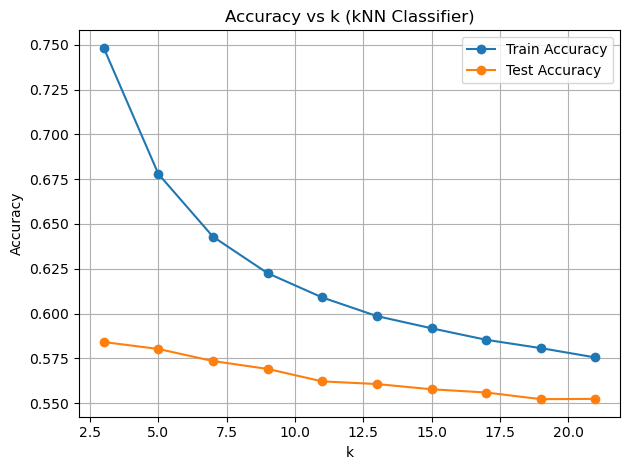

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load your PCA data
npz_path = "/Users/nithish/Downloads/yelp_pca_data.npz"
data = np.load(npz_path)
X_train = data['X_train_pca']
X_test = data['X_test_pca']
y_train = data['y_train']
y_test = data['y_test']

# Range of k values to try
k_values = list(range(3, 22, 2))  # 3, 5, 7, ..., 21
train_accuracies = []
test_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, weights='uniform', metric='euclidean')
    knn.fit(X_train, y_train)
    train_accuracies.append(accuracy_score(y_train, knn.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, knn.predict(X_test)))
    print(f"k={k} ✅ Train: {train_accuracies[-1]:.4f}, Test: {test_accuracies[-1]:.4f}")

# Plot results
plt.plot(k_values, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(k_values, test_accuracies, label='Test Accuracy', marker='o')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('Accuracy vs k (kNN Classifier)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


As we can see @ k= 3 our train and test accuracy are maximum

✅ Loaded PCA data
🚀 Final kNN training (k=3) complete

✅ Final Train Accuracy: 0.7483
✅ Final Test Accuracy:  0.5841

📊 Final Train Classification Report:
              precision    recall  f1-score   support

       drink       0.78      0.62      0.69     12536
        food       0.86      0.77      0.81     16000
      inside       0.83      0.68      0.75     16000
        menu       0.58      0.99      0.73     16000
     outside       0.89      0.65      0.75     14855

    accuracy                           0.75     75391
   macro avg       0.79      0.74      0.75     75391
weighted avg       0.79      0.75      0.75     75391


📊 Final Test Classification Report:
              precision    recall  f1-score   support

       drink       0.57      0.33      0.42      3134
        food       0.75      0.59      0.66      4000
      inside       0.63      0.46      0.54      4000
        menu       0.46      0.97      0.62      4000
     outside       0.76      0.51      0.61     

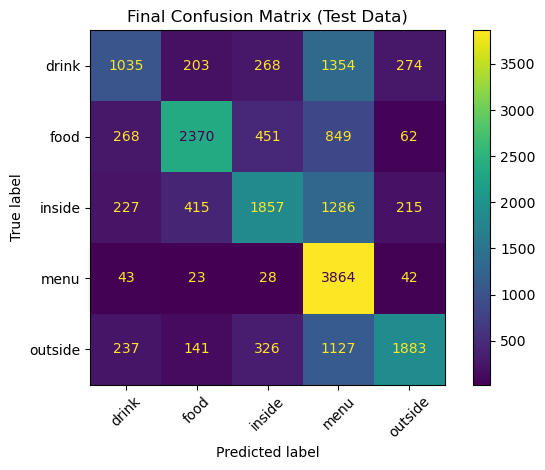

💾 Saved kNN model to: /Users/nithish/Downloads/final_knn_model_k3.pkl


In [1]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# === Step 1: Load PCA-transformed data ===
npz_path = "/Users/nithish/Downloads/yelp_pca_data.npz"
data = np.load(npz_path)

X_train_pca = data['X_train_pca']
X_test_pca = data['X_test_pca']
y_train = data['y_train']
y_test = data['y_test']

print("✅ Loaded PCA data")

# === Step 2: Train kNN with k=3 ===
knn = KNeighborsClassifier(n_neighbors=3, weights='uniform', metric='euclidean')
knn.fit(X_train_pca, y_train)
print("🚀 Final kNN training (k=3) complete")

# === Step 3: Predictions ===
y_train_pred = knn.predict(X_train_pca)
y_test_pred = knn.predict(X_test_pca)

# === Step 4: Accuracy ===
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"\n✅ Final Train Accuracy: {train_acc:.4f}")
print(f"✅ Final Test Accuracy:  {test_acc:.4f}")

# === Step 5: Classification Report ===
target_names = ['drink', 'food', 'inside', 'menu', 'outside']
print("\n📊 Final Train Classification Report:")
print(classification_report(y_train, y_train_pred, target_names=target_names))

print("\n📊 Final Test Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=target_names))

# === Step 6: Confusion Matrix ===
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, display_labels=target_names, cmap='viridis')
plt.title("Final Confusion Matrix (Test Data)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



# Model Interpretability:

In [5]:
import os
import numpy as np
from PIL import Image

base_path = "/Users/nithish/Desktop/Yelp JSON/Yelp Photos/yelp_photos/balanced_labeled_photos"
image_size = (112, 112)
class_names = ['drink', 'food', 'inside', 'menu', 'outside']
label_map = {cls: i for i, cls in enumerate(class_names)}

X = []
y = []
max_per_class = 200  # Reduce as needed

for cls in class_names:
    folder = os.path.join(base_path, cls)
    count = 0
    for filename in os.listdir(folder):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            try:
                img_path = os.path.join(folder, filename)
                img = Image.open(img_path).convert("RGB").resize(image_size)
                flat = np.array(img).flatten()
                X.append(flat)
                y.append(label_map[cls])
                count += 1
                if count >= max_per_class:
                    break
            except:
                continue

X = np.array(X)
y = np.array(y)
print(f"✅ Loaded {X.shape[0]} images. Shape: {X.shape}")


✅ Loaded 1000 images. Shape: (1000, 37632)


In [6]:
from sklearn.decomposition import PCA

# Fit PCA on your loaded training images
pca = PCA(n_components=200, random_state=42)
X_train_pca = pca.fit_transform(X)

print("✅ PCA fitted on 1000 images.")


✅ PCA fitted on 1000 images.


In [7]:
from sklearn.neighbors import KNeighborsClassifier

# Train kNN with k=3
knn = KNeighborsClassifier(n_neighbors=3, weights='uniform', metric='euclidean')
knn.fit(X_train_pca, y)

print("✅ kNN model trained.")


✅ kNN model trained.


  0%|          | 0/1000 [00:00<?, ?it/s]

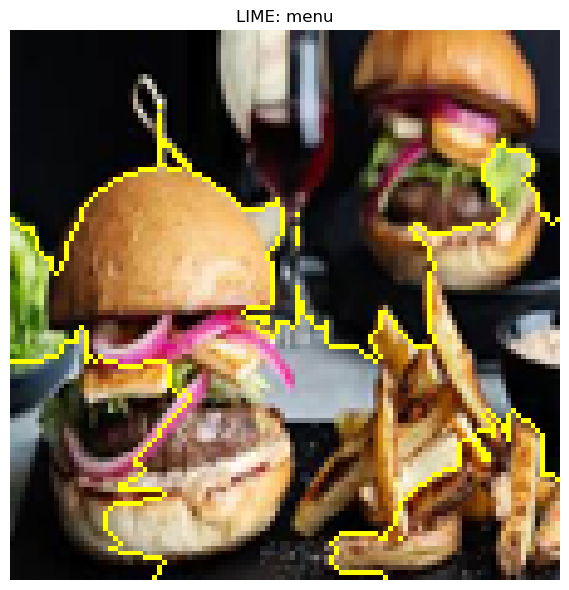

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries
from PIL import Image

# === Settings ===
image_path = "/Users/nithish/Downloads/test4.jpeg"
image_size = (112, 112)
class_names = ['drink', 'food', 'inside', 'menu', 'outside']

# === Load and preprocess the test image ===
original_image = Image.open(image_path).convert("RGB").resize(image_size)
image_array = np.array(original_image)
flat_image = image_array.flatten().reshape(1, -1)

# === Predict PCA and label ===
X_image_pca = pca.transform(flat_image)
predicted_label = knn.predict(X_image_pca)[0]

# === Define LIME-compatible classifier_fn ===
def knn_predict(images):
    flat_images = np.array([img.flatten() for img in images])
    transformed = pca.transform(flat_images)
    return knn.predict_proba(transformed)

# === Run LIME ===
explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(
    image_array,
    classifier_fn=knn_predict,
    top_labels=5,
    hide_color=0,
    num_samples=1000
)

# === Visualize Explanation ===
temp, mask = explanation.get_image_and_mask(
    label=predicted_label,
    positive_only=True,
    hide_rest=False
)

plt.figure(figsize=(6, 6))
plt.imshow(mark_boundaries(temp, mask))
plt.title(f"LIME: {class_names[predicted_label]}")
plt.axis('off')
plt.tight_layout()
plt.show()


# Why not to use KNN?
- In high dimensions, distances become less meaningful.
- kNN very slow for large datasets such as images
- it is just a memory-based algorithm which doesnt learn patterns